In [1]:
import pygmo as pg
import numpy as np
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

delta = 0.25

In [3]:
location = "bulk"
occupations_old = np.zeros(24)
mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=-1, U=0, delta=delta, occupations= occupations_old
    )
problem = Problem(
        structure_path=mean_field_problem.structure_path, 
        structure_name=mean_field_problem.structure_name)
mean_field_problem._set_eigenvalues(problem, occupations_old, debug=True)
problem.setup(
    N_r = 10,
    N_k = 200,
    location = location,
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.25, 't_pp_pi': -0.75, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.25, 't_pp_pi': -0.75, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'C': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': np.float64(0.0), 'n_px_down': np.float64(0.0), 'n_py_up': np.float64(0.0), 'n_py_down': np.float64(0.0), 'n_pz_up': np.float64(0.0), 'n_pz_down': np.float64(0.0)}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.25, 't_pp_pi': -0.75}, 'C': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': -1.25, 't_p

In [4]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

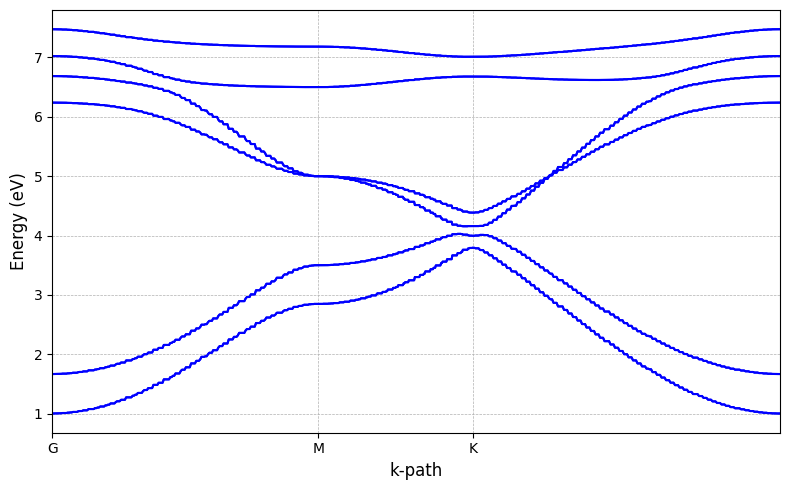

In [5]:
j_3_2 = [i for i in range(8, 24)]
tb_bulk.plot_band_structure(g, bands=j_3_2)

In [6]:
mean_field_problem.setup(11, 1, 0.05, T = 300, N_h = 2)

In [7]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)

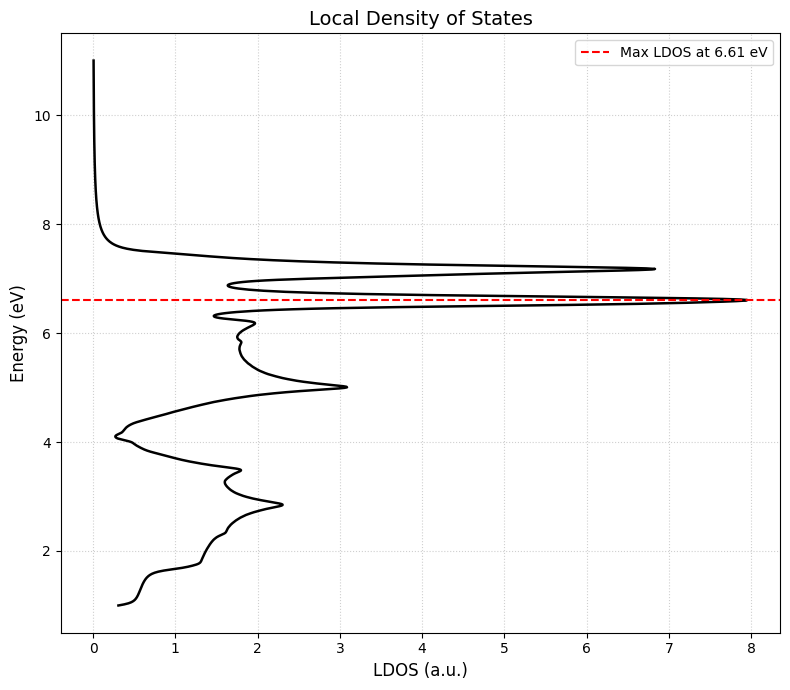

In [8]:
invariants.plot_density_of_states(E, DOS)

In [11]:
U = 0.6
N_h = 3
location = "bulk"
tol = 1e-4
occupations_old = np.zeros(24)
converged_e, converged_h = False, False
counter = 0
results = {}
while not converged_e:
    mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=-1, U=U, delta=delta, occupations= occupations_old
    )
    mean_field_problem.setup(10, -10, 0.05, T = 300, N_h = N_h)
    problem = Problem(
            structure_path=mean_field_problem.structure_path, 
            structure_name=mean_field_problem.structure_name)
    mean_field_problem._set_eigenvalues(problem, occupations_old)
    problem.setup(
        N_r = 10,
        N_k = 200,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    g = problem.geometry
    tb_bulk = problem.hamiltonian[location]["tight_binding"]
    invariants = problem.hamiltonian["bulk"]["topological_invariants"]
    E, DOS = mean_field_problem.density_of_states(
        g, tb_bulk, invariants, mean_field_problem.E_max, 
        mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)
    mu_max = np.max(E) + 10
    mu_min = np.min(E) - 10
    mu = mean_field_problem.find_chemical_potential(
        E, DOS, mean_field_problem.N_h, mean_field_problem.T, 
        mu_max, mu_min
    )
    occ_e, occ_h = mean_field_problem.get_occupations(
        g, tb_bulk, E, mu, mean_field_problem.T
    )
    results[counter] = occ_e
    diff_e = np.abs(occupations_old - occ_e)
    converged_e = np.all(diff_e < tol)
    diff_h = np.abs(np.sum(occ_h) -N_h)
    converged_h =  np.all(diff_h < tol)
    print(counter, diff_h, diff_e)
    occupations_old = occ_e
    counter +=1

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
0 0.09809217834293582 [1.         1.         0.63900647 0.63900647 0.69176685 0.69176685
 0.7690097  0.7690097  1.         1.         0.63900647 0.63900647
 0.69176685 0.69176685 0.7690097  0.7690097  1.         1.
 0.71753683 0.71756395 0.61200767 0.61203478 0.76841696 0.76838984]
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 0.1099711393064271 [0.00000000e+00 0.00000000e+00 1.87099072e-01 1.87097473e-01
 1.91087262e-01 1.91086187e-01 2.02744040e-01 2.02747646e-01
 1.26565425e-14 6.77236045e-15 1.87099072e-01 1.87097473e-01
 1.91087262e-01 1.91086187e-01 2.02744040e-01 2.02747646e-01
 5.32907052e-15 1.33226763e-15 1.93752953e-01 1.93775229e-01
 1.84023515e-01 1.84047524e-01 2.02904473e-01 2.02883897e-01]
Building Geomet

KeyboardInterrupt: 

In [13]:
np.savetxt(f"results/occupations_symmetric_U={U}_delta=025.txt", occ_e)

In [12]:
occ_e

array([1.        , 1.        , 0.58432352, 0.58432353, 0.63572526,
       0.63572528, 0.70758527, 0.70758523, 1.        , 1.        ,
       0.58432352, 0.58432353, 0.63572526, 0.63572528, 0.70758527,
       0.70758523, 1.        , 1.        , 0.66043496, 0.66043498,
       0.55902076, 0.55902078, 0.70698765, 0.70698761])